In [39]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import pandas as pd
from scipy import stats
import random
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Configure matplotlib for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported successfully!")
print("NetworkX version:", nx.__version__)
print("NumPy version:", np.__version__)

All libraries imported successfully!
NetworkX version: 3.5
NumPy version: 2.0.2


In [40]:
def create_ring_lattice(n: int, k: int) -> nx.Graph:
    """
    Create a ring lattice network (base network before rewiring).

    Parameters:
    - n: number of nodes
    - k: each node connected to k nearest neighbors (k/2 on each side)

    Returns:
    - NetworkX graph object
    """
    G = nx.Graph()
    G.add_nodes_from(range(n))

    # Connect each node to k/2 neighbors on each side
    for i in range(n):
        for j in range(1, k//2 + 1):
            # Connect to neighbors on the right
            neighbor_right = (i + j) % n
            G.add_edge(i, neighbor_right)

            # Connect to neighbors on the left
            neighbor_left = (i - j) % n
            G.add_edge(i, neighbor_left)

    return G

def add_long_ties(G: nx.Graph, p: float) -> nx.Graph:
    """
    Add long ties by rewiring edges with probability p.
    This creates the "small world" effect.

    Parameters:
    - G: original graph
    - p: probability of rewiring each edge

    Returns:
    - Graph with long ties added
    """
    G_rewired = G.copy()
    edges = list(G_rewired.edges())

    for edge in edges:
        if np.random.random() < p:
            # Remove the original edge
            G_rewired.remove_edge(edge[0], edge[1])

            # Add a random long-range connection
            # Choose a random node that's not already connected
            node1 = edge[0]
            possible_targets = [n for n in G_rewired.nodes()
                              if n != node1 and not G_rewired.has_edge(node1, n)]

            if possible_targets:
                node2 = np.random.choice(possible_targets)
                G_rewired.add_edge(node1, node2)

    return G_rewired

def analyze_network_properties(G: nx.Graph) -> Dict:
    """
    Analyze key properties of the network.
    """
    properties = {
        'num_nodes': G.number_of_nodes(),
        'num_edges': G.number_of_edges(),
        'avg_degree': np.mean([d for n, d in G.degree()]),
        'clustering_coefficient': nx.average_clustering(G),
        'avg_path_length': nx.average_shortest_path_length(G) if nx.is_connected(G) else np.inf,
        'is_connected': nx.is_connected(G)
    }
    return properties

In [41]:
class ContagionSimulator:
    """
    Simulator for noisy threshold-based contagions.
    """

    def __init__(self, G: nx.Graph, threshold: int, noise: float = 0.01):
        """
        Initialize the contagion simulator.

        Parameters:
        - G: network graph
        - threshold: number of adopted neighbors needed for adoption
        - noise: probability of adopting below threshold
        """
        self.G = G
        self.threshold = threshold
        self.noise = noise
        self.reset_simulation()

    def reset_simulation(self):
        """Reset the simulation state."""
        self.adopted = set()
        self.time_step = 0
        self.adoption_history = []

    def seed_adoption(self, num_seeds: int = 1, seed_nodes: List[int] = None):
        """
        Seed the contagion with initial adopters.

        Parameters:
        - num_seeds: number of initial adopters (if seed_nodes not specified)
        - seed_nodes: specific nodes to seed (optional)
        """
        if seed_nodes is None:
            seed_nodes = np.random.choice(list(self.G.nodes()),
                                        size=num_seeds, replace=False)

        self.adopted.update(seed_nodes)
        self.adoption_history.append(len(self.adopted))

    def step(self) -> int:
        """
        Perform one step of the contagion process.

        Returns:
        - Number of new adopters in this step
        """
        new_adopters = set()

        for node in self.G.nodes():
            if node not in self.adopted:
                # Count adopted neighbors
                adopted_neighbors = sum(1 for neighbor in self.G.neighbors(node)
                                      if neighbor in self.adopted)

                # Decide whether to adopt
                if adopted_neighbors >= self.threshold:
                    # Adopt if threshold is met
                    new_adopters.add(node)
                elif np.random.random() < self.noise:
                    # Adopt with noise probability even if threshold not met
                    new_adopters.add(node)

        # Update adopted set
        self.adopted.update(new_adopters)
        self.time_step += 1
        self.adoption_history.append(len(self.adopted))

        return len(new_adopters)

    def run_simulation(self, max_steps: int = 1000) -> List[int]:
        """
        Run the complete simulation until convergence or max steps.

        Returns:
        - List of adoption counts at each time step
        """
        for _ in range(max_steps):
            new_adopters = self.step()
            if new_adopters == 0:  # Convergence reached
                break

        return self.adoption_history

    def get_final_adoption_rate(self) -> float:
        """Get the final adoption rate (fraction of nodes adopted)."""
        return len(self.adopted) / self.G.number_of_nodes()

In [42]:
def run_single_experiment(n: int, k: int, p: float, threshold: int,
                         noise: float, num_seeds: int = 1) -> Dict:
    """
    Run a single contagion experiment.

    Returns:
    - Dictionary with experiment results
    """
    # Create network
    G_base = create_ring_lattice(n, k)
    G_rewired = add_long_ties(G_base, p)

    # Run simulation
    sim = ContagionSimulator(G_rewired, threshold, noise)
    sim.seed_adoption(num_seeds)
    adoption_history = sim.run_simulation()

    # Analyze results
    results = {
        'network_properties': analyze_network_properties(G_rewired),
        'adoption_history': adoption_history,
        'final_adoption_rate': sim.get_final_adoption_rate(),
        'time_to_convergence': len(adoption_history) - 1,
        'parameters': {
            'n': n, 'k': k, 'p': p, 'threshold': threshold,
            'noise': noise, 'num_seeds': num_seeds
        }
    }

    return results

def run_multiple_experiments(n: int, k: int, p_values: List[float],
                           threshold: int, noise: float, num_runs: int = 10) -> pd.DataFrame:
    """
    Run multiple experiments to compare different rewiring probabilities.

    Returns:
    - DataFrame with aggregated results
    """
    results = []

    for p in p_values:
        print(f"Running experiments with p = {p:.3f}...")

        for run in range(num_runs):
            result = run_single_experiment(n, k, p, threshold, noise)

            # Extract key metrics
            row = {
                'p': p,
                'run': run,
                'final_adoption_rate': result['final_adoption_rate'],
                'time_to_convergence': result['time_to_convergence'],
                'clustering_coefficient': result['network_properties']['clustering_coefficient'],
                'avg_path_length': result['network_properties']['avg_path_length']
            }
            results.append(row)

    return pd.DataFrame(results)

In [43]:
def plot_network_comparison(n: int = 50, k: int = 4, p: float = 0.1):
    """
    Visualize the difference between regular and rewired networks.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Regular ring lattice
    G_regular = create_ring_lattice(n, k)
    pos_regular = nx.circular_layout(G_regular)

    axes[0].set_title('Regular Ring Lattice (p=0)')
    nx.draw(G_regular, pos_regular, ax=axes[0], node_size=50,
            node_color='lightblue', edge_color='gray', width=0.5)

    # Rewired network
    G_rewired = add_long_ties(G_regular, p)
    pos_rewired = nx.circular_layout(G_rewired)

    axes[1].set_title(f'Network with Long Ties (p={p})')
    nx.draw(G_rewired, pos_rewired, ax=axes[1], node_size=50,
            node_color='lightcoral', edge_color='gray', width=0.5)

    plt.tight_layout()
    plt.show()

def plot_adoption_curves(experiments_data: List[Dict], labels: List[str]):
    """
    Plot adoption curves for different experiments.
    """
    plt.figure(figsize=(10, 6))

    for i, (data, label) in enumerate(zip(experiments_data, labels)):
        adoption_history = data['adoption_history']
        time_steps = range(len(adoption_history))
        n_nodes = data['parameters']['n']

        # Convert to adoption rate
        adoption_rates = [count / n_nodes for count in adoption_history]

        plt.plot(time_steps, adoption_rates, label=label, linewidth=2, marker='o', markersize=4)

    plt.xlabel('Time Steps')
    plt.ylabel('Adoption Rate')
    plt.title('Contagion Spread Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, None)
    plt.ylim(0, 1)
    plt.show()

def plot_experiment_results(df: pd.DataFrame):
    """
    Plot results from multiple experiments.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Final adoption rate vs p
    axes[0, 0].set_title('Final Adoption Rate vs Rewiring Probability')
    sns.boxplot(data=df, x='p', y='final_adoption_rate', ax=axes[0, 0])
    axes[0, 0].set_ylabel('Final Adoption Rate')

    # Time to convergence vs p
    axes[0, 1].set_title('Time to Convergence vs Rewiring Probability')
    sns.boxplot(data=df, x='p', y='time_to_convergence', ax=axes[0, 1])
    axes[0, 1].set_ylabel('Time Steps to Convergence')

    # Clustering coefficient vs p
    axes[1, 0].set_title('Clustering Coefficient vs Rewiring Probability')
    sns.scatterplot(data=df, x='p', y='clustering_coefficient', ax=axes[1, 0])
    axes[1, 0].set_ylabel('Clustering Coefficient')

    # Average path length vs p
    axes[1, 1].set_title('Average Path Length vs Rewiring Probability')
    sns.scatterplot(data=df, x='p', y='avg_path_length', ax=axes[1, 1])
    axes[1, 1].set_ylabel('Average Path Length')

    plt.tight_layout()
    plt.show()

In [44]:
def main_experiment():
    """
    Run the main experiments to replicate key findings from the paper.
    """
    print("=" * 60)
    print("SOCIAL CONTAGION SIMULATION")
    print("Implementing: Long ties accelerate noisy threshold-based contagions")
    print("=" * 60)

    # Parameters
    n = 100          # Number of nodes
    k = 4            # Degree in ring lattice
    threshold = 2    # Adoption threshold
    noise = 0.01     # Noise probability
    num_seeds = 1    # Number of initial adopters

    print(f"\nParameters:")
    print(f"- Network size: {n} nodes")
    print(f"- Ring lattice degree: {k}")
    print(f"- Adoption threshold: {threshold}")
    print(f"- Noise probability: {noise}")
    print(f"- Initial adopters: {num_seeds}")

    # Experiment 1: Compare networks with different rewiring probabilities
    print("\n" + "="*50)
    print("EXPERIMENT 1: Network Structure Comparison")
    print("="*50)

    # Visualize network structures
    print("\nVisualizing network structures...")
    plot_network_comparison(n=30, k=4, p=0.1)

    # Experiment 2: Single contagion runs
    print("\n" + "="*50)
    print("EXPERIMENT 2: Single Contagion Runs")
    print("="*50)

    p_values = [0.0, 0.01, 0.1, 0.5]
    experiments = []
    labels = []

    for p in p_values:
        print(f"\nRunning simulation with p = {p}...")
        result = run_single_experiment(n, k, p, threshold, noise, num_seeds)
        experiments.append(result)
        labels.append(f"p = {p}")

        # Print results
        props = result['network_properties']
        print(f"  Final adoption rate: {result['final_adoption_rate']:.3f}")
        print(f"  Time to convergence: {result['time_to_convergence']} steps")
        print(f"  Clustering coefficient: {props['clustering_coefficient']:.3f}")
        print(f"  Average path length: {props['avg_path_length']:.3f}")

    # Plot adoption curves
    print("\nPlotting adoption curves...")
    plot_adoption_curves(experiments, labels)

    # Experiment 3: Multiple runs for statistical analysis
    print("\n" + "="*50)
    print("EXPERIMENT 3: Statistical Analysis")
    print("="*50)

    print("Running multiple experiments for statistical analysis...")
    p_values_detailed = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5]

    df_results = run_multiple_experiments(
        n=n, k=k, p_values=p_values_detailed,
        threshold=threshold, noise=noise, num_runs=5
    )

    # Plot results
    print("Plotting statistical results...")
    plot_experiment_results(df_results)

    # Summary statistics
    print("\n" + "="*50)
    print("SUMMARY STATISTICS")
    print("="*50)

    summary = df_results.groupby('p').agg({
        'final_adoption_rate': ['mean', 'std'],
        'time_to_convergence': ['mean', 'std'],
        'clustering_coefficient': 'mean',
        'avg_path_length': 'mean'
    }).round(3)

    print(summary)

    # Key findings
    print("\n" + "="*50)
    print("KEY FINDINGS")
    print("="*50)

    # Compare p=0 vs p>0
    p0_data = df_results[df_results['p'] == 0.0]
    p_pos_data = df_results[df_results['p'] > 0.0]

    avg_time_p0 = p0_data['time_to_convergence'].mean()
    avg_time_p_pos = p_pos_data['time_to_convergence'].mean()

    print(f"1. Average time to convergence:")
    print(f"   - Regular network (p=0): {avg_time_p0:.1f} steps")
    print(f"   - Networks with long ties (p>0): {avg_time_p_pos:.1f} steps")
    print(f"   - Speed improvement: {((avg_time_p0 - avg_time_p_pos) / avg_time_p0 * 100):.1f}%")

    # Final adoption comparison
    avg_adoption_p0 = p0_data['final_adoption_rate'].mean()
    avg_adoption_p_pos = p_pos_data['final_adoption_rate'].mean()

    print(f"\n2. Average final adoption rate:")
    print(f"   - Regular network (p=0): {avg_adoption_p0:.3f}")
    print(f"   - Networks with long ties (p>0): {avg_adoption_p_pos:.3f}")

    print(f"\n3. Long ties accelerate contagion spread while maintaining high adoption rates.")
    print(f"   This confirms the main finding of the paper!")

    return df_results

In [45]:
def noise_sensitivity_experiment():
    """
    Experiment to study the effect of noise on contagion spread.
    """
    print("\n" + "="*50)
    print("NOISE SENSITIVITY EXPERIMENT")
    print("="*50)

    n = 100
    k = 4
    threshold = 2
    p = 0.1  # Fixed rewiring probability
    noise_values = [0.0, 0.001, 0.01, 0.05, 0.1]

    results = []

    for noise in noise_values:
        print(f"Testing noise = {noise}...")

        # Run multiple trials
        adoption_rates = []
        convergence_times = []

        for _ in range(10):
            result = run_single_experiment(n, k, p, threshold, noise)
            adoption_rates.append(result['final_adoption_rate'])
            convergence_times.append(result['time_to_convergence'])

        results.append({
            'noise': noise,
            'avg_adoption_rate': np.mean(adoption_rates),
            'avg_convergence_time': np.mean(convergence_times),
            'std_adoption_rate': np.std(adoption_rates),
            'std_convergence_time': np.std(convergence_times)
        })

    # Plot results
    df_noise = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].errorbar(df_noise['noise'], df_noise['avg_adoption_rate'],
                     yerr=df_noise['std_adoption_rate'], marker='o', capsize=5)
    axes[0].set_xlabel('Noise Probability')
    axes[0].set_ylabel('Final Adoption Rate')
    axes[0].set_title('Effect of Noise on Final Adoption')
    axes[0].grid(True, alpha=0.3)

    axes[1].errorbar(df_noise['noise'], df_noise['avg_convergence_time'],
                     yerr=df_noise['std_convergence_time'], marker='o', capsize=5)
    axes[1].set_xlabel('Noise Probability')
    axes[1].set_ylabel('Time to Convergence')
    axes[1].set_title('Effect of Noise on Convergence Speed')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nNoise sensitivity results:")
    print(df_noise)

In [46]:
def interactive_demo():
    """
    Interactive demonstration of the contagion process.
    """
    print("\n" + "="*50)
    print("INTERACTIVE DEMO")
    print("="*50)

    print("This demo shows how contagion spreads step by step.")
    print("You can modify the parameters below to see different behaviors.")

    # Parameters for demo
    n = 20           # Smaller network for visualization
    k = 4
    threshold = 2
    noise = 0.02
    p = 0.1

    # Create network
    G = create_ring_lattice(n, k)
    G = add_long_ties(G, p)

    # Initialize simulation
    sim = ContagionSimulator(G, threshold, noise)
    sim.seed_adoption(num_seeds=2)

    # Visualize initial state
    plt.figure(figsize=(12, 8))

    # Run simulation step by step
    for step in range(min(10, n)):  # Show first 10 steps or until convergence
        plt.subplot(2, 5, step + 1)

        # Create node colors based on adoption status
        node_colors = ['red' if node in sim.adopted else 'lightblue'
                      for node in G.nodes()]

        # Draw network
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, node_color=node_colors, node_size=200,
                with_labels=True, font_size=8)

        plt.title(f'Step {step}\nAdopted: {len(sim.adopted)}/{n}')

        # Perform simulation step
        new_adopters = sim.step()
        if new_adopters == 0:
            break

    plt.tight_layout()
    plt.show()

    print(f"\nFinal adoption rate: {sim.get_final_adoption_rate():.3f}")

SOCIAL CONTAGION SIMULATION
Implementing: Long ties accelerate noisy threshold-based contagions

Parameters:
- Network size: 100 nodes
- Ring lattice degree: 4
- Adoption threshold: 2
- Noise probability: 0.01
- Initial adopters: 1

EXPERIMENT 1: Network Structure Comparison

Visualizing network structures...


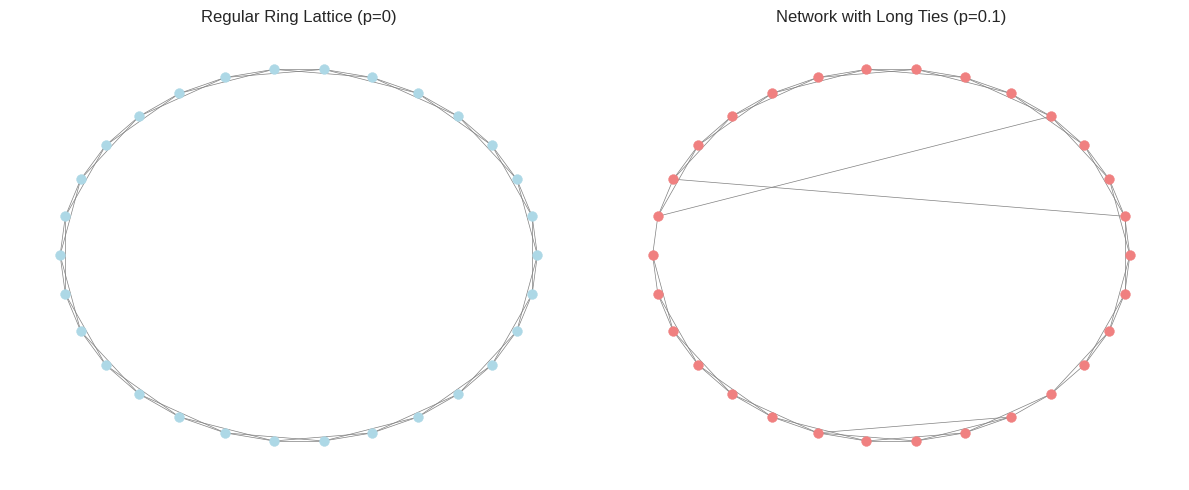


EXPERIMENT 2: Single Contagion Runs

Running simulation with p = 0.0...
  Final adoption rate: 0.010
  Time to convergence: 1 steps
  Clustering coefficient: 0.500
  Average path length: 12.879

Running simulation with p = 0.01...
  Final adoption rate: 0.020
  Time to convergence: 2 steps
  Clustering coefficient: 0.486
  Average path length: 11.235

Running simulation with p = 0.1...
  Final adoption rate: 0.010
  Time to convergence: 1 steps
  Clustering coefficient: 0.391
  Average path length: 5.136

Running simulation with p = 0.5...
  Final adoption rate: 0.160
  Time to convergence: 11 steps
  Clustering coefficient: 0.120
  Average path length: 3.524

Plotting adoption curves...


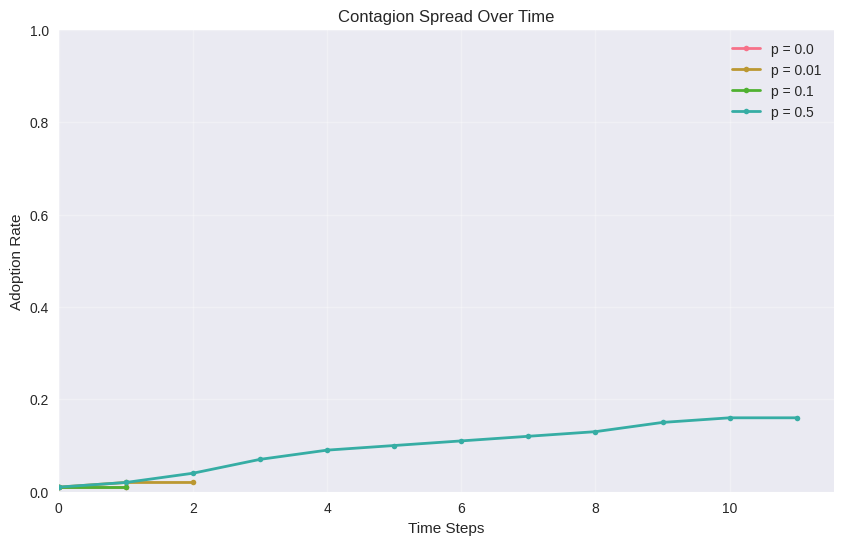


EXPERIMENT 3: Statistical Analysis
Running multiple experiments for statistical analysis...
Running experiments with p = 0.000...
Running experiments with p = 0.001...
Running experiments with p = 0.010...
Running experiments with p = 0.050...
Running experiments with p = 0.100...
Running experiments with p = 0.200...
Running experiments with p = 0.500...
Plotting statistical results...


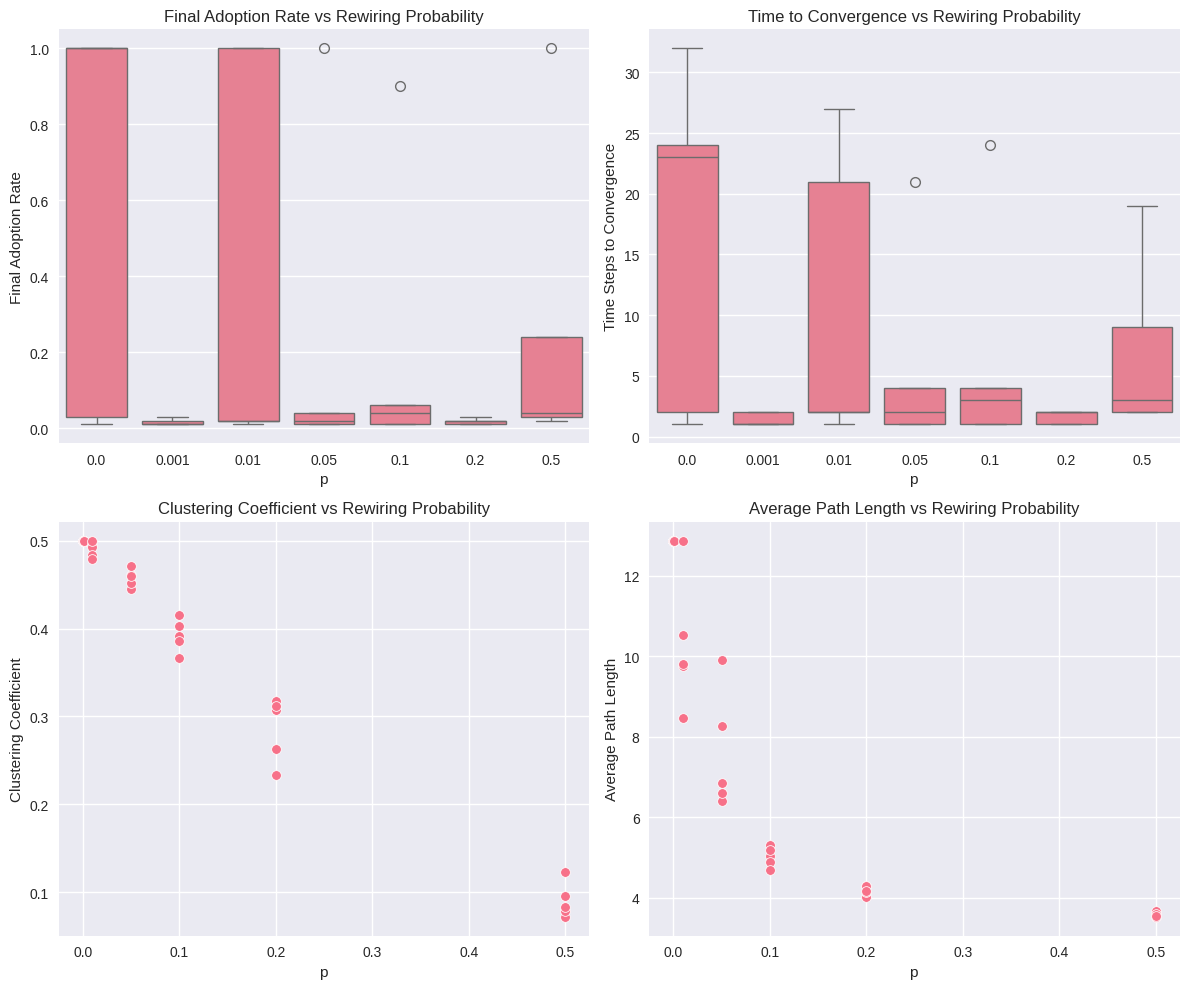


SUMMARY STATISTICS
      final_adoption_rate        time_to_convergence          \
                     mean    std                mean     std   
p                                                              
0.000               0.608  0.537                16.4  14.046   
0.001               0.016  0.009                 1.4   0.548   
0.010               0.410  0.539                10.6  12.422   
0.050               0.216  0.438                 5.8   8.585   
0.100               0.204  0.390                 6.6   9.813   
0.200               0.018  0.008                 1.6   0.548   
0.500               0.266  0.420                 7.0   7.314   

      clustering_coefficient avg_path_length  
                        mean            mean  
p                                             
0.000                  0.500          12.879  
0.001                  0.500          12.879  
0.010                  0.490          10.287  
0.050                  0.458           7.611  
0.100     

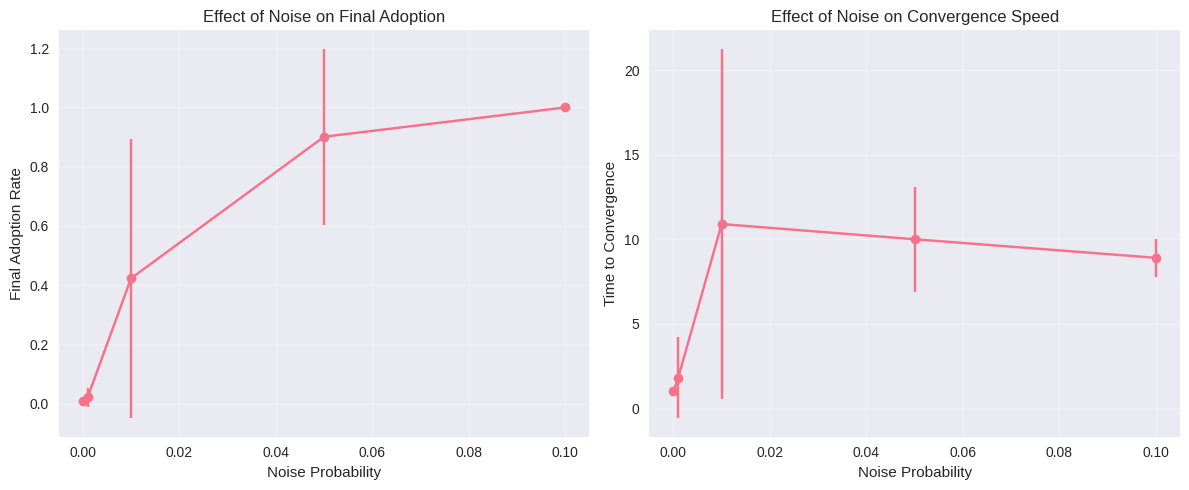


Noise sensitivity results:
   noise  avg_adoption_rate  avg_convergence_time  std_adoption_rate  \
0  0.000              0.010                   1.0       1.734723e-18   
1  0.001              0.021                   1.8       3.300000e-02   
2  0.010              0.423                  10.9       4.721663e-01   
3  0.050              0.901                  10.0       2.970000e-01   
4  0.100              1.000                   8.9       0.000000e+00   

   std_convergence_time  
0              0.000000  
1              2.400000  
2             10.377379  
3              3.098387  
4              1.135782  

INTERACTIVE DEMO
This demo shows how contagion spreads step by step.
You can modify the parameters below to see different behaviors.


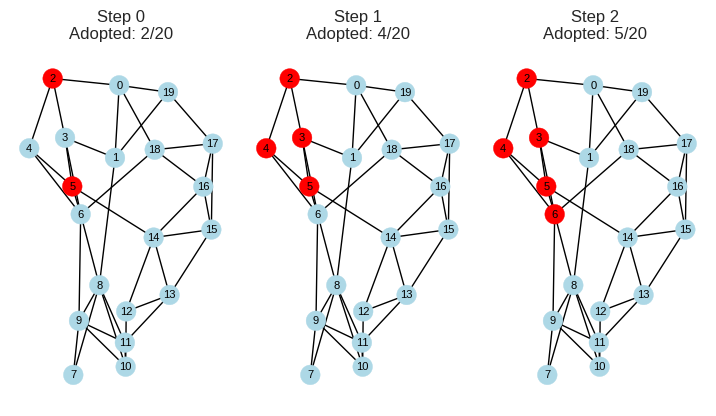


Final adoption rate: 0.250

EXPERIMENT COMPLETED!

To run specific parts of the code, just call:
- main_experiment() for the main analysis
- noise_sensitivity_experiment() for noise analysis
- interactive_demo() for step-by-step visualization


In [48]:
if __name__ == "__main__":
    # Run main experiment
    results_df = main_experiment()

    # Run additional experiments
    noise_sensitivity_experiment()

    # Run interactive demo
    interactive_demo()

    print("\n" + "="*60)
    print("EXPERIMENT COMPLETED!")
    print("="*60)
    print("\nTo run specific parts of the code, just call:")
    print("- main_experiment() for the main analysis")
    print("- noise_sensitivity_experiment() for noise analysis")
    print("- interactive_demo() for step-by-step visualization")
